# Random LASSO 재현 (v2)

논문 *Hi-LASSO* Section 3 벤치마크의 **Random LASSO**(Wang 2011, 2단계 부트스트랩)를 재현한다.
데이터·채점은 `lib/`의 generate_data·scoring을 그대로 재사용(LASSO·ENet과 **동일 데이터**), 솔버만 `lib/random_lasso.py`로 교체.
**우선 Dataset I·II만**(III·IV는 부트스트랩이 무거워 미룸).

# Part A · 준비

## 1. 환경 & 모듈 import

이 노트북은 **R을 쓰지 않는다**(내부 솔버 = sklearn LassoCV). lib 3모듈 중 solver는 불필요.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join("..", "lib")))
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings; warnings.filterwarnings("ignore")   # LassoCV 수렴 경고 억제

import generate_data as gd
from generate_data import DATASETS, SIGMA, BASE_SEED, SEED_BETA, build_beta, generate_split, snr
import scoring
from scoring import rme, rme_nonzeros, rmse, f1_selection, aucpr
import random_lasso
from random_lasso import fit_random_lasso

print("modules loaded (R 불필요, 내부 솔버 = sklearn LassoCV)")

modules loaded (R 불필요, 내부 솔버 = sklearn LassoCV)


## 2. 전역 설정

`DATASETS_RL`로 Dataset I·II만 대상(III·IV는 이름만 추가하면 확장). threshold는 **반복마다 검증셋 예측오차(MSE) 최소로 자동 선택**(정직; 참 β 미사용, 01/02의 λ 선택과 동일 원리).

In [2]:
METHOD    = "RandomLASSO"
N_REPEAT  = 10
L         = 30          # 부트스트랩 배수: B = floor(L*p/q)
N_JOBS    = 64          # 병렬 코어 (112코어 중 64)
# threshold는 반복마다 검증셋 MSE 최소로 자동 선택 (정직; 참 β 미사용)
DATASETS_RL = {k: DATASETS[k] for k in ["Dataset I", "Dataset II", "Dataset III", "Dataset IV"]}
print("대상:", list(DATASETS_RL.keys()), "| L=%d, N_REPEAT=%d, threshold=검증셋 자동선택" % (L, N_REPEAT))

대상: ['Dataset I', 'Dataset II', 'Dataset III', 'Dataset IV'] | L=30, N_REPEAT=10, threshold=검증셋 자동선택


## 3. lib 검산 & 부트스트랩 수

동일 데이터 SNR과 각 데이터셋의 부트스트랩 수 B를 확인.

In [3]:
for name, cfg in DATASETS_RL.items():
    beta = build_beta(cfg)
    tr, va, te = generate_split(cfg, beta, rep=0)
    print("%-11s p=%-5d n_tr=%-4d SNR=%.3f  B=floor(L*p/n)=%d" % (
        name, cfg["p"], cfg["n_tr"], snr(cfg, beta), (L*cfg["p"])//cfg["n_tr"]))

Dataset I   p=100   n_tr=50   SNR=2.733  B=floor(L*p/n)=60


Dataset II  p=1000  n_tr=100  SNR=4.419  B=floor(L*p/n)=300
Dataset III p=10000 n_tr=200  SNR=4.419  B=floor(L*p/n)=1500
Dataset IV  p=10000 n_tr=400  SNR=4.419  B=floor(L*p/n)=750


# Part B · 한 번 돌려보기

## 4. 단일 데모 — 중요도 점수 (rep 0)

λ 탐색 자리 대체. Procedure 1이 **참 비영 변수(초록)** 에 높은 중요도를 주고 잡음(빨강)엔 낮게 주는지 확인.

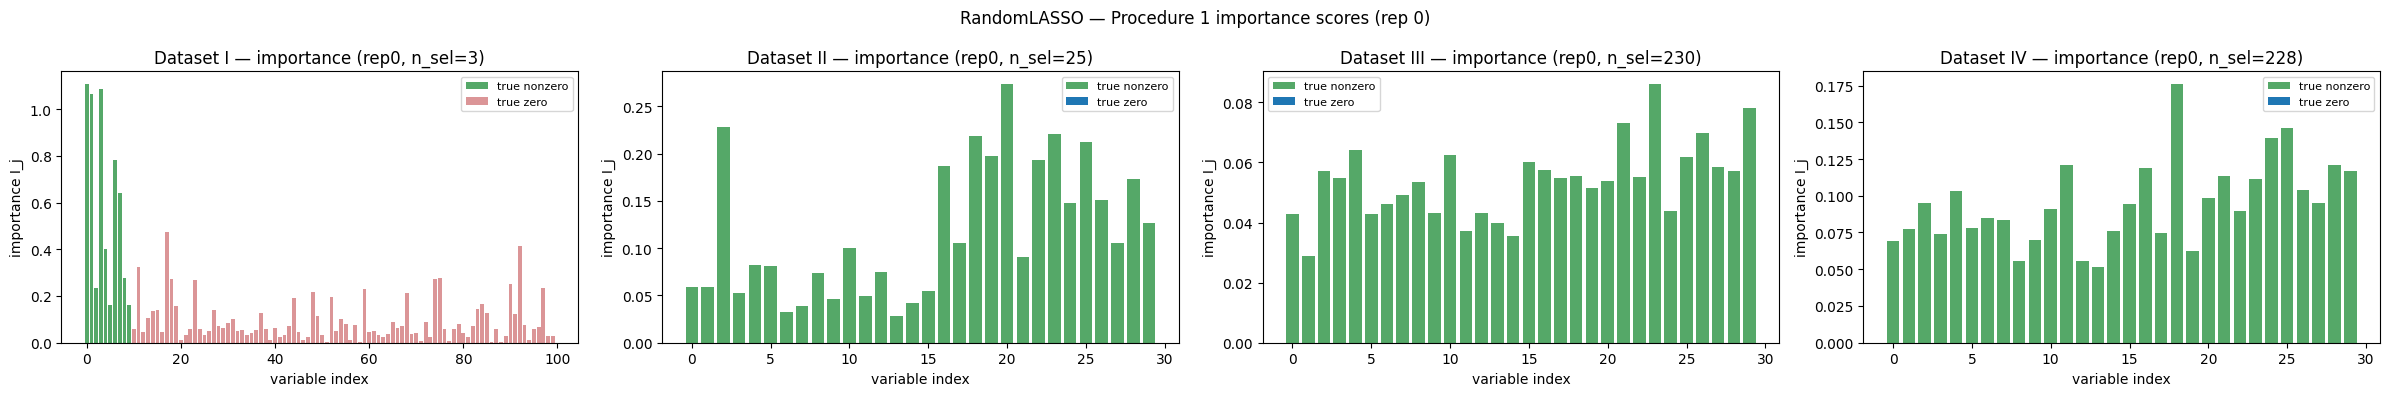

In [4]:
fig, axes = plt.subplots(1, len(DATASETS_RL), figsize=(6*len(DATASETS_RL), 4))
for ax, (name, cfg) in zip(np.atleast_1d(axes), DATASETS_RL.items()):
    beta = build_beta(cfg)
    (Xtr, ytr), (Xval, yval), _ = generate_split(cfg, beta, 0)
    r = fit_random_lasso(Xtr, ytr, Xval, yval, L=L, n_jobs=N_JOBS, random_state=0)
    k = 30 if cfg["p"] > 100 else cfg["p"]
    idx = np.arange(k); true = (beta[:k] != 0)
    ax.bar(idx[true], r["importance_"][:k][true], color="#55A868", label="true nonzero")
    ax.bar(idx[~true], r["importance_"][:k][~true], color="#C44E52", alpha=0.6, label="true zero")
    ax.set_xlabel("variable index"); ax.set_ylabel("importance I_j")
    ax.set_title(f"{name} — importance (rep0, n_sel={r['n_selected']})")
    ax.legend(fontsize=8)
fig.suptitle(f"{METHOD} — Procedure 1 importance scores (rep 0)")
plt.tight_layout(); plt.show()

## 5. β̂ vs β — rep 0 (계수 미리보기)

LASSO가 죽이던 음수 계수 β₃·β₆·β₁₀를 Random LASSO가 살리는지 미리보기(§11에서 10회로 확장).

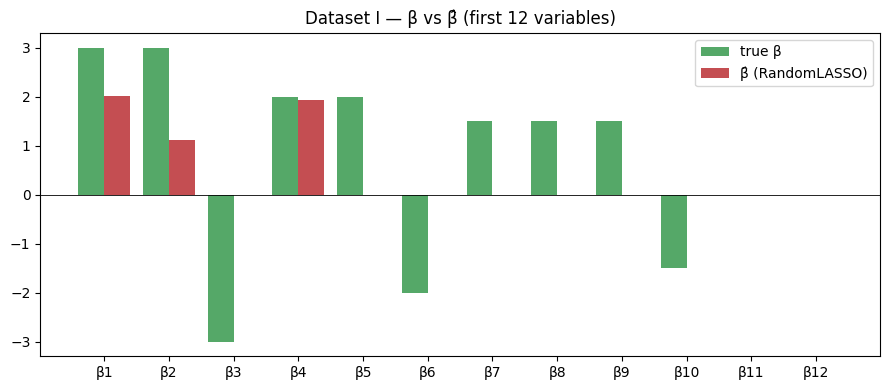

In [5]:
cfg = DATASETS_RL["Dataset I"]; beta = build_beta(cfg)
(Xtr, ytr), (Xval, yval), _ = generate_split(cfg, beta, 0)
r = fit_random_lasso(Xtr, ytr, Xval, yval, L=L, n_jobs=N_JOBS, random_state=0); bhat = r["coef_"]
k = 12; idx = np.arange(k); w = 0.4
plt.figure(figsize=(9, 4))
plt.bar(idx - w/2, beta[:k], w, label="true β", color="#55A868")
plt.bar(idx + w/2, bhat[:k], w, label=f"β̂ ({METHOD})", color="#C44E52")
plt.axhline(0, color='k', lw=0.6); plt.xticks(idx, [f"β{i+1}" for i in idx])
plt.title("Dataset I — β vs β̂ (first 12 variables)")
plt.legend(); plt.tight_layout(); plt.show()

# Part C · 본 실험 (I·II × 10회)

## 6. 전체 실험 루프

rep마다 `fit_random_lasso(Xtr,ytr)` → 채점. bhat·importance·n_selected를 details에 저장.

In [6]:
def run_experiment():
    records, details = [], {}
    for name, cfg in DATASETS_RL.items():
        beta = build_beta(cfg)
        d = dict(beta=beta, bhats=[], beta_hats=[], importances=[], n_selected=[], thresholds=[])
        for rep in range(N_REPEAT):
            (Xtr, ytr), (Xval, yval), (Xte, yte) = generate_split(cfg, beta, rep)
            r = fit_random_lasso(Xtr, ytr, Xval, yval, L=L, n_jobs=N_JOBS, random_state=rep)
            bhat = r["coef_"]; pred = Xte @ bhat
            records.append(dict(dataset=name, method=METHOD, rep=rep,
                                RME_All=rme(bhat, beta, cfg),
                                RME_Nonzeros=rme_nonzeros(bhat, beta, cfg),
                                RMSE=rmse(yte, pred),
                                aucpr=aucpr(r["beta_hat_"], beta),
                                **f1_selection(bhat, beta)))
            d["bhats"].append(bhat); d["beta_hats"].append(r["beta_hat_"])
            d["importances"].append(r["importance_"])
            d["n_selected"].append(r["n_selected"]); d["thresholds"].append(r["threshold_"])
        details[name] = d
        print(f"{name}: {N_REPEAT} reps done")
    return records, details

records, details = run_experiment()
df = pd.DataFrame(records)
metrics = ["RME_All", "RME_Nonzeros", "RMSE", "f1", "aucpr"]
print("총 레코드:", len(records))

Dataset I: 10 reps done


Dataset II: 10 reps done


Dataset III: 10 reps done


Dataset IV: 10 reps done
총 레코드: 40


In [ ]:
# 05 비교 노트북용: per-rep 지표(CSV) + beta_hats(NPZ) 저장
df.to_csv("../results_random_lasso.csv", index=False)
np.savez_compressed("../results_random_lasso.npz",
    **{f"{k}__beta_hats": np.array(v["beta_hats"]) for k, v in details.items()},
    **{f"{k}__beta": v["beta"] for k, v in details.items()})
print("saved: ../results_random_lasso.csv + .npz")

## 7. 결과 표 (평균 ± 표준오차)

In [7]:
summary = df.groupby(["dataset", "method"])[metrics].agg(["mean", "sem"]).round(4)
summary

RME_All         RME_Nonzeros            RMSE          \
                           mean     sem         mean     sem    mean     sem   
dataset     method                                                             
Dataset I   RandomLASSO  1.3940  0.1178       1.2962  0.1470  4.6247  0.3780   
Dataset II  RandomLASSO  1.6350  0.0746       1.5600  0.0691  4.7526  0.3664   
Dataset III RandomLASSO  1.7089  0.0665       1.6861  0.0661  4.8861  0.1489   
Dataset IV  RandomLASSO  1.2622  0.0303       1.2271  0.0302  4.5676  0.1274   

                             f1           aucpr          
                           mean     sem    mean     sem  
dataset     method                                       
Dataset I   RandomLASSO  0.3836  0.0392  0.5678  0.0323  
Dataset II  RandomLASSO  0.3564  0.0210  0.3705  0.0194  
Dataset III RandomLASSO  0.2747  0.0092  0.5907  0.0279  
Dataset IV  RandomLASSO  0.1966  0.0041  0.4296  0.0121

## 8. 논문 Table 3 비교 (Random_EG 열)

우리 구현은 Proc2에 순수 LASSO를 쓰므로 논문의 **Random_EG**(generic) 열과 비교.

In [8]:
PAPER_RANDOM_EG = {   # 논문 Table 3, Random_EG 열 (AUCPR은 논문 미제공 → 비교 제외)
    "Dataset I":  dict(RME_All=1.4688, RME_Nonzeros=1.4238, RMSE=4.1216, f1=0.4237),
    "Dataset II": dict(RME_All=2.4894, RME_Nonzeros=2.4026, RMSE=5.7314, f1=0.1816),
    "Dataset III": dict(RME_All=4.7696, RME_Nonzeros=4.1757, RMSE=7.3016, f1=0.4114),
    "Dataset IV":  dict(RME_All=4.3766, RME_Nonzeros=4.3766, RMSE=7.0131, f1=0.5860),
}
paper_metrics = ["RME_All", "RME_Nonzeros", "RMSE", "f1"]   # 논문에 있는 지표만
rows = []
for ds in DATASETS_RL:
    if ds not in PAPER_RANDOM_EG: continue
    ours = df[df.dataset == ds][paper_metrics].mean()
    for m in paper_metrics:
        rows.append(dict(dataset=ds, metric=m, ours=round(float(ours[m]), 4), paper=PAPER_RANDOM_EG[ds][m]))
compare = pd.DataFrame(rows)
compare["ratio(ours/paper)"] = (compare["ours"] / compare["paper"]).round(2)
compare

,dataset,metric,ours,paper,ratio(ours/paper)
0,Dataset I,RME_All,1.3940,1.4688,0.95
1,Dataset I,RME_Nonzeros,1.2962,1.4238,0.91
2,Dataset I,RMSE,4.6247,4.1216,1.12
3,Dataset I,f1,0.3836,0.4237,0.91
4,Dataset II,RME_All,1.6350,2.4894,0.66
5,Dataset II,RME_Nonzeros,1.5600,2.4026,0.65
6,Dataset II,RMSE,4.7526,5.7314,0.83
7,Dataset II,f1,0.3564,0.1816,1.96
8,Dataset III,RME_All,1.7089,4.7696,0.36
9,Dataset III,RME_Nonzeros,1.6861,4.1757,0.40


# Part D · 분포 시각화

## 9. 지표 막대 (평균 ± 표준오차)

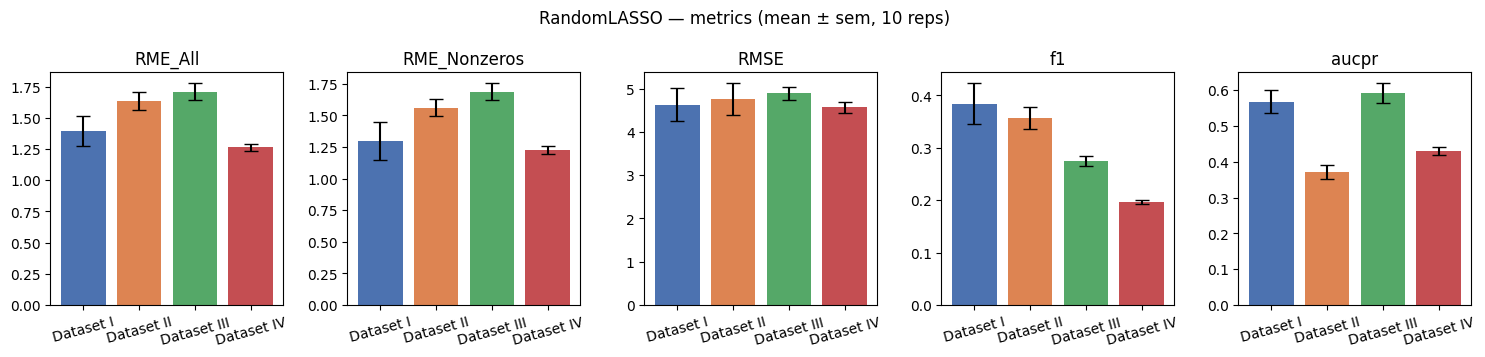

In [9]:
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
fig, axes = plt.subplots(1, len(metrics), figsize=(15, 3.6))
for ax, m in zip(axes, metrics):
    sub = df.groupby("dataset")[m].agg(["mean", "sem"])
    ax.bar(range(len(sub)), sub["mean"], yerr=sub["sem"], capsize=5, color=colors[:len(sub)])
    ax.set_xticks(range(len(sub))); ax.set_xticklabels(sub.index, rotation=15); ax.set_title(m)
fig.suptitle(f"{METHOD} — metrics (mean ± sem, {N_REPEAT} reps)")
plt.tight_layout(); plt.show()

## 10. 지표 분포 박스플롯 (10회)

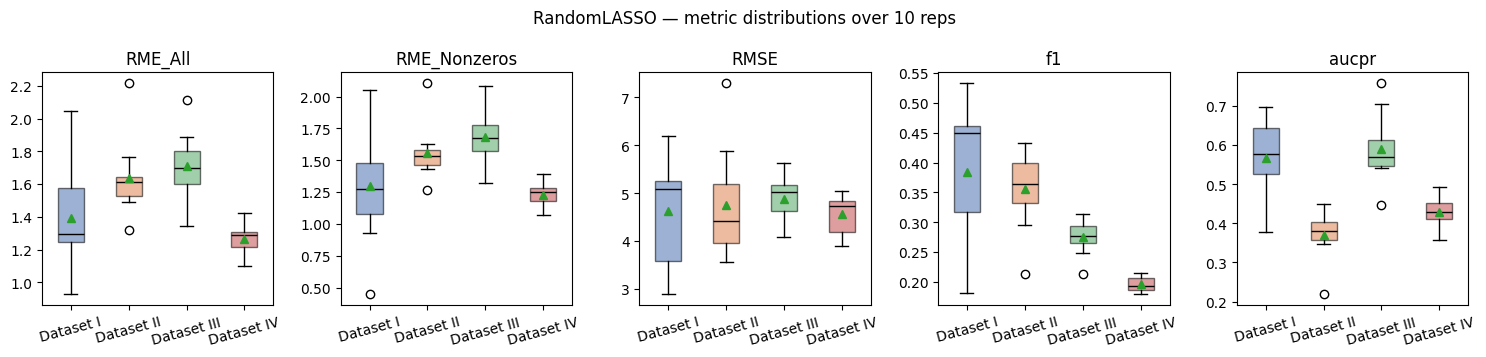

In [10]:
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
fig, axes = plt.subplots(1, len(metrics), figsize=(15, 3.6))
for ax, m in zip(axes, metrics):
    data = [df[df.dataset == ds][m].values for ds in DATASETS_RL]
    bp = ax.boxplot(data, patch_artist=True, showmeans=True, medianprops=dict(color='k'))
    for patch, c in zip(bp['boxes'], colors): patch.set_facecolor(c); patch.set_alpha(0.55)
    ax.set_xticks(range(1, len(DATASETS_RL)+1)); ax.set_xticklabels(list(DATASETS_RL.keys()), rotation=15); ax.set_title(m)
fig.suptitle(f"{METHOD} — metric distributions over {N_REPEAT} reps")
plt.tight_layout(); plt.show()

## 11. 계수 부호 산점도 (10회)

Dataset I 앞 10개. Random LASSO가 음수 계수 β₃·β₆·β₁₀를 LASSO보다 잘 살리는지가 관전 포인트.

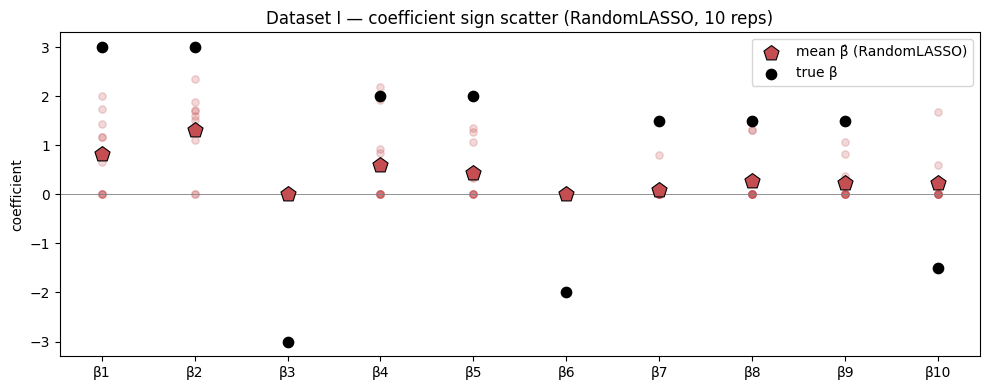

In [11]:
k = 10; d = details["Dataset I"]; beta_I = d["beta"]
bhats = np.array([bh[:k] for bh in d["bhats"]])
idx = np.arange(k)
plt.figure(figsize=(10, 4))
for rep in range(N_REPEAT):
    plt.scatter(idx, bhats[rep], color="#C44E52", alpha=0.22, s=28, zorder=2)
plt.scatter(idx, bhats.mean(0), color="#C44E52", marker='p', s=130, edgecolor='k', lw=0.8, zorder=3, label=f"mean β̂ ({METHOD})")
plt.scatter(idx, beta_I[:k], color='k', marker='o', s=55, zorder=4, label="true β")
plt.axhline(0, color='gray', lw=0.6); plt.xticks(idx, [f"β{i+1}" for i in idx])
plt.title(f"Dataset I — coefficient sign scatter ({METHOD}, {N_REPEAT} reps)")
plt.ylabel("coefficient"); plt.legend(); plt.tight_layout(); plt.show()

## 12. 선택 변수 수 분포 (λ 안정성 대체)

반복별 선택 변수 수. 점선 = 참 비영 개수(과다/과소선택 확인).

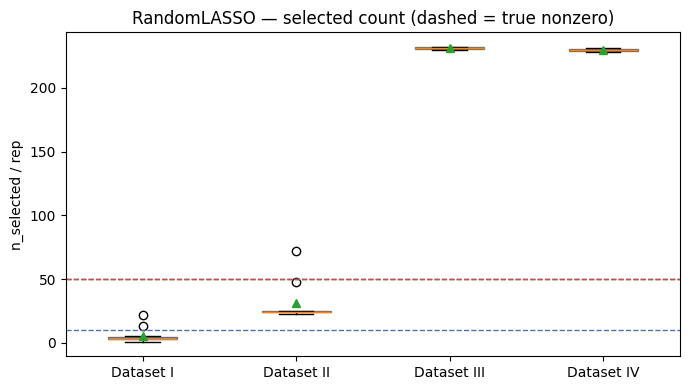

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
data = [details[name]["n_selected"] for name in DATASETS_RL]
bp = ax.boxplot(data, patch_artist=True, showmeans=True)
cs = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
for patch, c in zip(bp['boxes'], cs): patch.set_facecolor(c); patch.set_alpha(0.5)
for i, name in enumerate(DATASETS_RL):
    ax.axhline(int((details[name]["beta"] != 0).sum()), color=cs[i], ls="--", lw=1)
ax.set_xticks(range(1, len(DATASETS_RL)+1)); ax.set_xticklabels(list(DATASETS_RL.keys()))
ax.set_ylabel("n_selected / rep"); ax.set_title(f"{METHOD} — selected count (dashed = true nonzero)")
plt.tight_layout(); plt.show()

## 13. 검증 MSE vs threshold 곡선 (I·II, rep 0)

01/02의 "λ 탐색 곡선"의 Random 판. 반복마다 t를 **검증 예측오차 최소**로 고르는데, 그 U자 곡선과 선택된 t(빨간 점선)를 보여준다. 정답 β 없이 데이터로 t가 정해지는 과정.

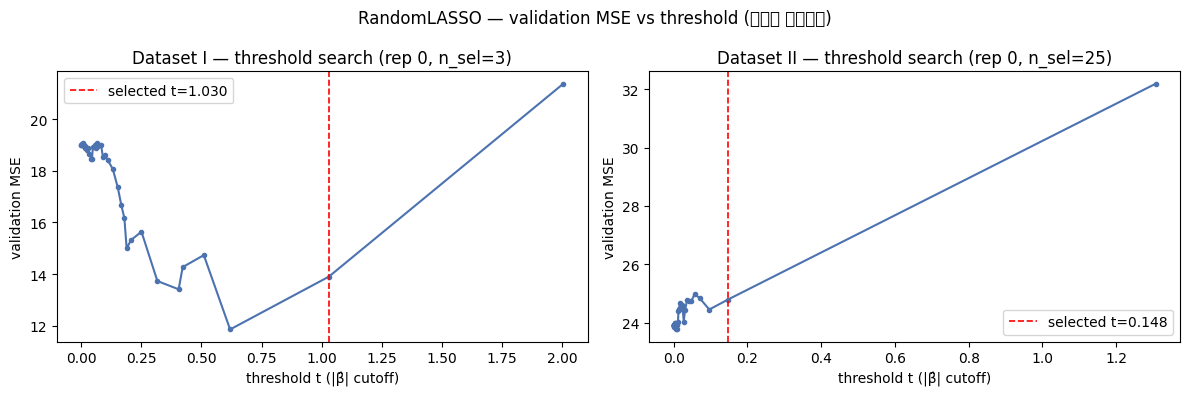

In [13]:
demo = ["Dataset I", "Dataset II"]
fig, axes = plt.subplots(1, len(demo), figsize=(6*len(demo), 4))
for ax, name in zip(np.atleast_1d(axes), demo):
    cfg = DATASETS_RL[name]; beta = build_beta(cfg)
    (Xtr, ytr), (Xval, yval), _ = generate_split(cfg, beta, 0)
    r = fit_random_lasso(Xtr, ytr, Xval, yval, L=L, n_jobs=N_JOBS, random_state=0)
    ax.plot(r["thr_grid_"], r["thr_mse_"], marker='.', color="#4C72B0")
    ax.axvline(r["threshold_"], color='r', ls='--', lw=1.2, label=f"selected t={r['threshold_']:.3f}")
    ax.set_xlabel("threshold t (|β̂| cutoff)"); ax.set_ylabel("validation MSE")
    ax.set_title(f"{name} — threshold search (rep 0, n_sel={r['n_selected']})")
    ax.legend()
fig.suptitle(f"{METHOD} — validation MSE vs threshold (검증셋 자동선택)")
plt.tight_layout(); plt.show()

## 14. 선택 threshold 분포 (10회)

검증이 반복마다 고른 t의 분포. 좁을수록 threshold 선택이 안정적(01/02 λ 안정성의 Random 판).

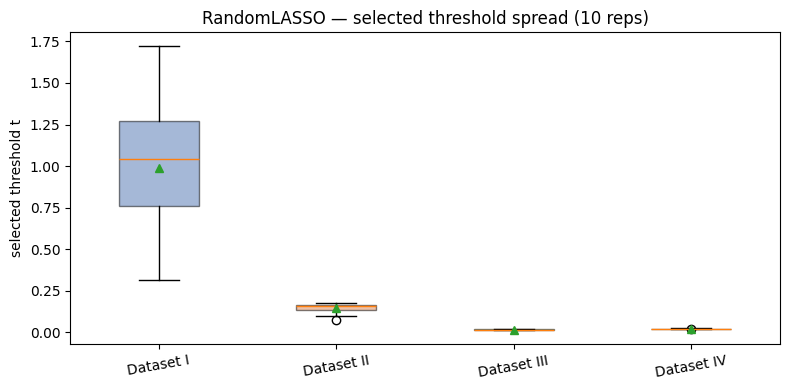

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
data = [details[name]["thresholds"] for name in DATASETS_RL]
cs = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
bp = ax.boxplot(data, patch_artist=True, showmeans=True)
for patch, c in zip(bp['boxes'], cs): patch.set_facecolor(c); patch.set_alpha(0.5)
ax.set_xticks(range(1, len(DATASETS_RL)+1)); ax.set_xticklabels(list(DATASETS_RL.keys()), rotation=10)
ax.set_ylabel("selected threshold t"); ax.set_title(f"{METHOD} — selected threshold spread ({N_REPEAT} reps)")
plt.tight_layout(); plt.show()

## 15. Precision-Recall 곡선 & AUCPR (rep 0)

threshold-free 평가. |β̂| 순위로 그린 PR 곡선과 그 면적(AUCPR). 곡선이 오른쪽 위에 붙을수록(면적 큼) 신호/잡음 분리가 좋다. 임계값 선택 문제 자체를 우회하는 정직한 지표.

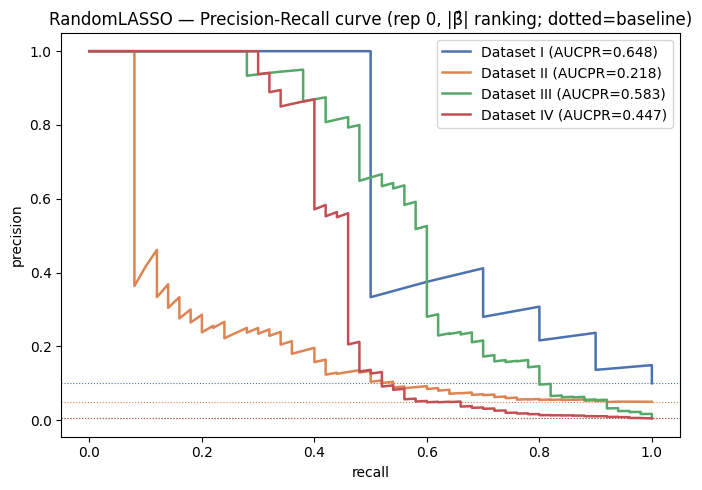

In [15]:
from sklearn.metrics import precision_recall_curve, average_precision_score
fig, ax = plt.subplots(figsize=(7, 5))
cs = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
for i, name in enumerate(DATASETS_RL):
    beta = details[name]["beta"]; score = np.abs(details[name]["beta_hats"][0])
    ytrue = (beta != 0).astype(int)
    prec, rec, _ = precision_recall_curve(ytrue, score)
    ap = average_precision_score(ytrue, score)
    ax.plot(rec, prec, color=cs[i], lw=1.8, label=f"{name} (AUCPR={ap:.3f})")
    ax.axhline(ytrue.mean(), color=cs[i], ls=":", lw=0.8)   # baseline = 유병률
ax.set_xlabel("recall"); ax.set_ylabel("precision")
ax.set_title(f"{METHOD} — Precision-Recall curve (rep 0, |β̂| ranking; dotted=baseline)")
ax.legend(); plt.tight_layout(); plt.show()